# Unemployment Analysis with Python

**OIBSIP Data Science — Task 2**

This notebook investigates regional and temporal unemployment patterns in India, with emphasis on the COVID-19 period.

## Dataset and methodology

The dataset contains monthly state/region observations from May 2019 to June 2020. The analysis cleans column names and numeric/date types, removes incomplete duplicates, derives an employment-rate proxy, and creates the charts required by the task card.

Dataset shape before cleaning: (768, 7)
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  
Removed 28 duplicate/incomplete rows
Clea

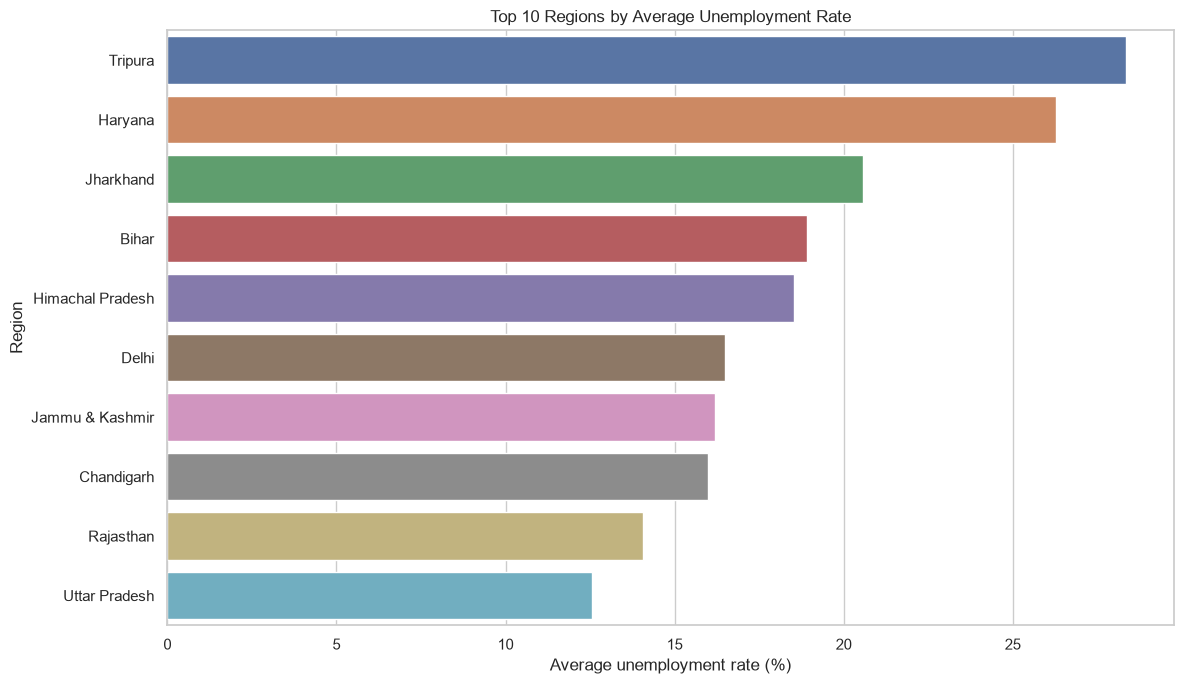

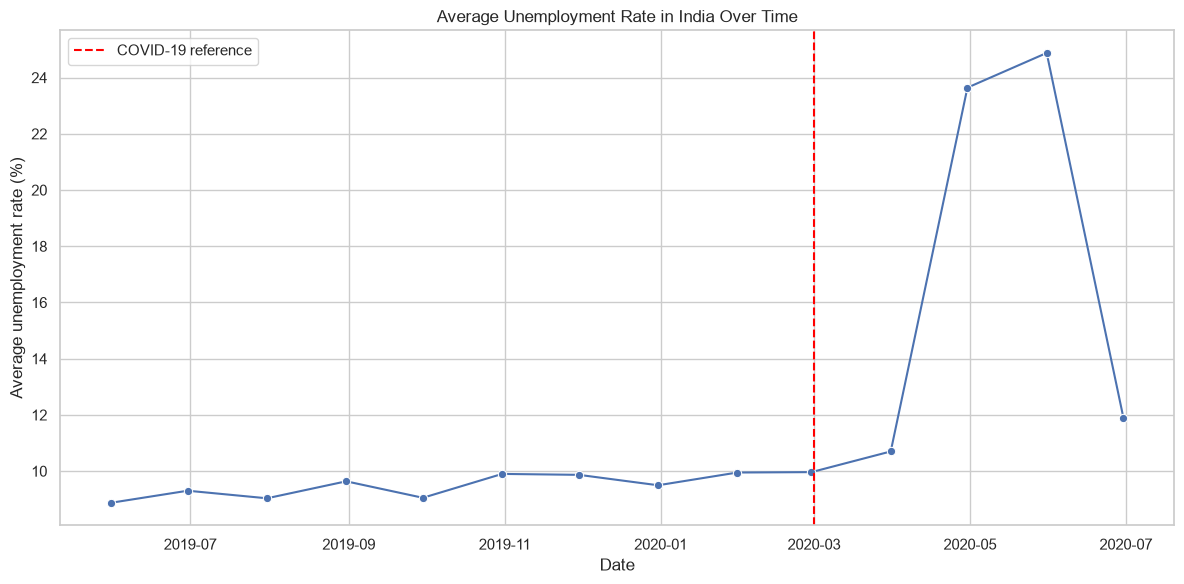

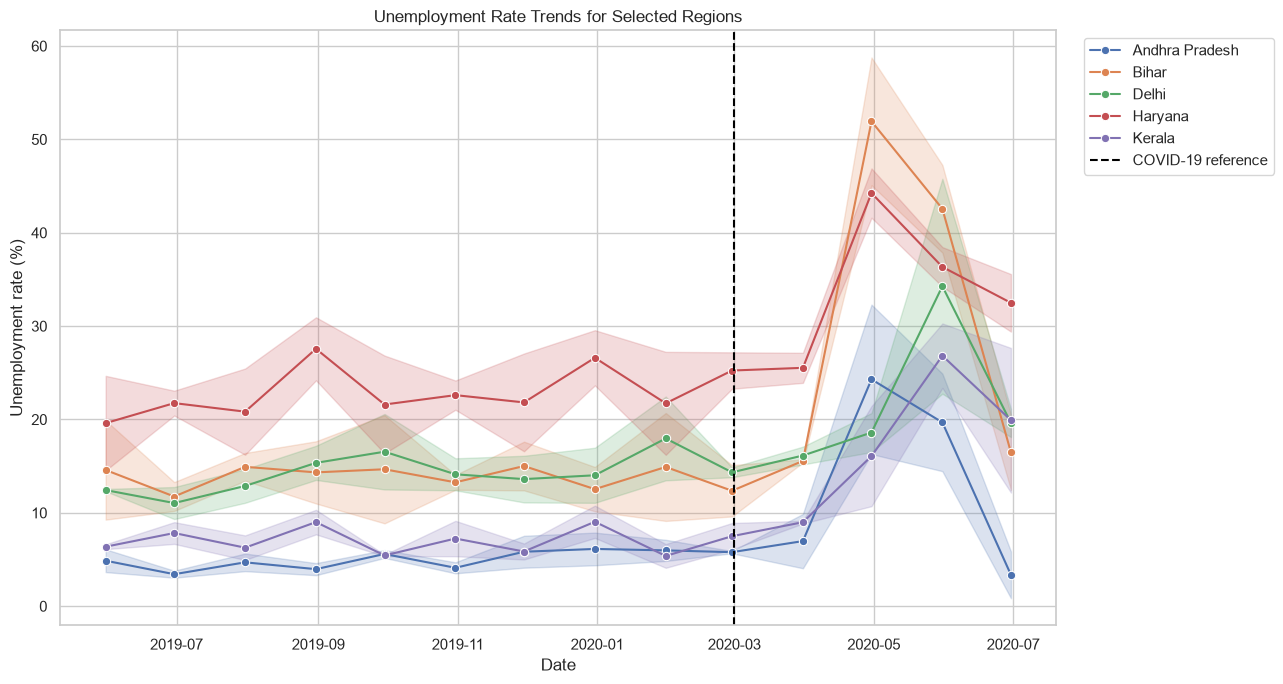

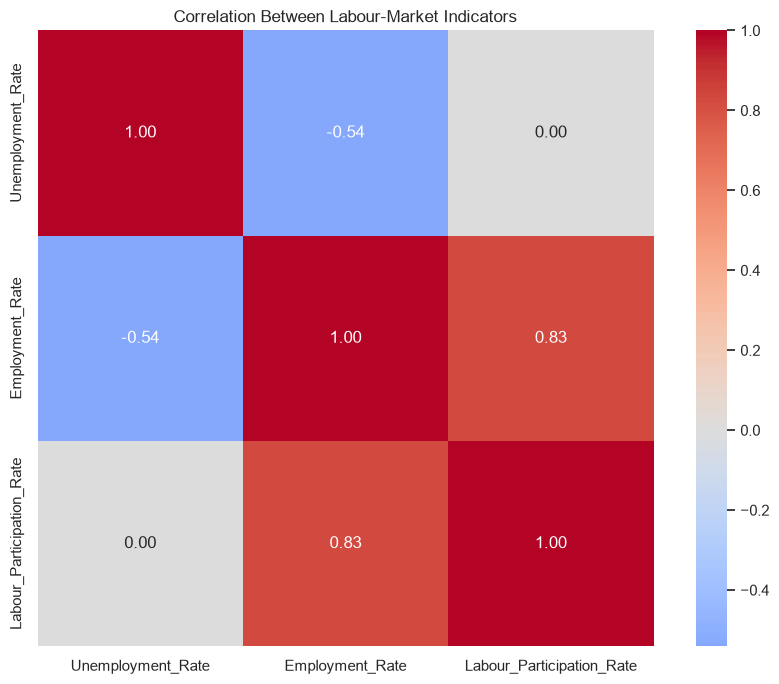

            Unemployment_Rate  Employment_Rate  Labour_Participation_Rate
Period                                                                   
Post-COVID              17.77            32.41                      39.33
Pre-COVID                9.51            39.58                      43.89


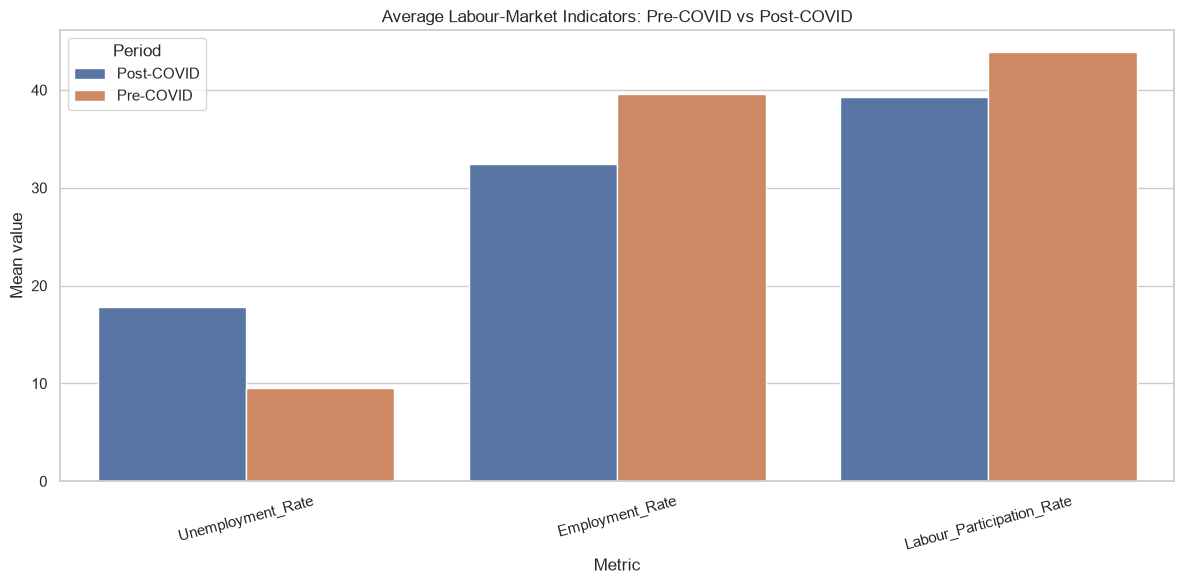

In [1]:
# Unemployment Analysis with Python — OIBSIP Data Science Task 2
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 6)
DATA_PATH = Path("Unemployment_in_India.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# 1. Load data
raw_df = pd.read_csv(DATA_PATH)
print("Dataset shape before cleaning:", raw_df.shape)
print(raw_df.head())

# 2. Clean names, types, duplicates, and missing values
df = raw_df.copy()
df.columns = df.columns.str.strip()
df = df.rename(columns={
    "Region.1": "Area",
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate"
})
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
for col in ["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

before = len(df)
df = df.drop_duplicates().dropna(subset=["Region", "Date", "Unemployment_Rate", "Employed", "Labour_Participation_Rate"])
df = df.sort_values(["Date", "Region"]).reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate/incomplete rows")
print("Cleaned shape:", df.shape)
print("Missing values:\n", df.isna().sum())
print("Date range:", df.Date.min().date(), "to", df.Date.max().date())

# The source provides employed population and labour participation, not employment rate.
# This derived rate is the employed share of the labour force proxy.
df["Employment_Rate"] = df["Labour_Participation_Rate"] * (1 - df["Unemployment_Rate"] / 100)

# 3. Region-wise average unemployment
region_avg = (df.groupby("Region", as_index=False)["Unemployment_Rate"]
              .mean().sort_values("Unemployment_Rate", ascending=False))
print(region_avg.head(10).round(2))
plt.figure(figsize=(12, 7))
sns.barplot(data=region_avg.head(10), x="Unemployment_Rate", y="Region", hue="Region", legend=False)
plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average unemployment rate (%)"); plt.ylabel("Region")
plt.tight_layout(); plt.savefig(OUTPUT_DIR/"top_10_regions.png", dpi=180); plt.show()

# 4. Month-wise trend
monthly_avg = df.groupby("Date", as_index=False)["Unemployment_Rate"].mean()
plt.figure(figsize=(12, 6)); sns.lineplot(data=monthly_avg, x="Date", y="Unemployment_Rate", marker="o")
plt.axvline(pd.Timestamp("2020-03-01"), ls="--", color="red", label="COVID-19 reference")
plt.title("Average Unemployment Rate in India Over Time"); plt.ylabel("Average unemployment rate (%)")
plt.legend(); plt.tight_layout(); plt.savefig(OUTPUT_DIR/"monthly_trend.png", dpi=180); plt.show()

# 5. Time-series chart for at least 3 regions
selected_regions = ["Andhra Pradesh", "Bihar", "Delhi", "Haryana", "Kerala"]
trend = df[df.Region.isin(selected_regions)]
plt.figure(figsize=(13, 7)); sns.lineplot(data=trend, x="Date", y="Unemployment_Rate", hue="Region", marker="o")
plt.axvline(pd.Timestamp("2020-03-01"), ls="--", color="black", label="COVID-19 reference")
plt.title("Unemployment Rate Trends for Selected Regions"); plt.ylabel("Unemployment rate (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left"); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"regional_time_series.png", dpi=180); plt.show()

# 6. Correlation heatmap
corr_cols = ["Unemployment_Rate", "Employment_Rate", "Labour_Participation_Rate"]
plt.figure(figsize=(9, 7)); sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Between Labour-Market Indicators"); plt.tight_layout()
plt.savefig(OUTPUT_DIR/"correlation_heatmap.png", dpi=180); plt.show()

# 7. Pre-COVID vs post-COVID comparison
# March 2020 is used as the boundary, matching the internship brief.
df["Period"] = np.where(df["Date"] < pd.Timestamp("2020-03-01"), "Pre-COVID", "Post-COVID")
period_summary = (df.groupby("Period")[corr_cols].mean().round(2))
print(period_summary)
period_plot = period_summary.reset_index().melt(id_vars="Period", var_name="Metric", value_name="Mean_Value")
plt.figure(figsize=(12, 6)); sns.barplot(data=period_plot, x="Metric", y="Mean_Value", hue="Period")
plt.title("Average Labour-Market Indicators: Pre-COVID vs Post-COVID"); plt.ylabel("Mean value")
plt.xticks(rotation=15); plt.tight_layout(); plt.savefig(OUTPUT_DIR/"pre_post_covid.png", dpi=180); plt.show()

# Save cleaned data and summary tables for reproducibility
df.to_csv(OUTPUT_DIR/"cleaned_unemployment_india.csv", index=False)
region_avg.to_csv(OUTPUT_DIR/"region_average_unemployment.csv", index=False)
period_summary.to_csv(OUTPUT_DIR/"pre_post_covid_summary.csv")


## Key observations

The charts and summary tables show regional differences, a sharp national increase around April–May 2020, and a higher post-COVID mean unemployment rate. Correlation describes association and does not establish causation.

## Limitations and reproducibility

The period is short and the measures are estimates. Run all cells from top to bottom after placing the CSV beside the notebook. The source and derived-rate definition are documented in README.md.